# Amazon ML Challenge 2026 — Business Entity Resolution
## Phase 1: Data Parsing + EDA

This notebook is **only for understanding the dataset**.

We will:
1. Locate and parse the four training TSV files.
2. Verify schema and basic data integrity.
3. Inspect missingness, duplicates, countries, text lengths and ground-truth match counts.
4. Sample the data to understand the noise patterns.
5. Compare S1 against S2/S3 at a descriptive level.

**Important:** We are deliberately **not** doing normalization, blocking, candidate generation, feature engineering, or model training yet. Those come after EDA.

The official challenge uses TSV files with columns:
`entity_id`, `business_name`, `business_address`, `country`.

Training also contains `train_ground_truth.tsv` with:
`source1_entity_id`, `matched_entity_ids`.


In [2]:
# ============================================================
# 0. Imports + configuration
# ============================================================

from pathlib import Path
import re
import json
import math
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")


# ============================================================
# Project paths
# ============================================================

# Notebook is currently inside:
#
# amazon_ml_entity_resolution/
# └── code/
#     └── business_entity_resolution/
#         └── src/
#
# Go 3 levels up to reach the project root.

PROJECT_DIR = Path("../../..").resolve()

DATA_DIR = PROJECT_DIR / "student_resource" / "dataset" / "train"
TEST_DIR = PROJECT_DIR / "student_resource" / "dataset" / "test"

CHUNK_SIZE = 100_000


print("Project directory:", PROJECT_DIR)
print("Training data:", DATA_DIR)
print("Test data:", TEST_DIR)


# ============================================================
# 1. Locate training files
# ============================================================

expected_files = [
    "train_source1.tsv",
    "train_source2.tsv",
    "train_source3.tsv",
    "train_ground_truth.tsv",
]

print("\nTraining files:")

for filename in expected_files:
    path = DATA_DIR / filename
    print(
        f"{filename:25} ->",
        "FOUND" if path.exists() else "MISSING"
    )


print("\nFiles actually visible in training directory:")

if DATA_DIR.exists():
    for p in sorted(DATA_DIR.glob("*")):
        print(" ", p.name)
else:
    print("ERROR: Training directory does not exist.")


# ============================================================
# 2. Locate test files
# ============================================================

expected_test_files = [
    "test_source1.tsv",
    "test_source2.tsv",
    "test_source3.tsv",
]

print("\nTest files:")

for filename in expected_test_files:
    path = TEST_DIR / filename
    print(
        f"{filename:25} ->",
        "FOUND" if path.exists() else "MISSING"
    )

Project directory: /Users/lakshmikotaru/amazon_ml_entity_resolution
Training data: /Users/lakshmikotaru/amazon_ml_entity_resolution/student_resource/dataset/train
Test data: /Users/lakshmikotaru/amazon_ml_entity_resolution/student_resource/dataset/test

Training files:
train_source1.tsv         -> FOUND
train_source2.tsv         -> FOUND
train_source3.tsv         -> FOUND
train_ground_truth.tsv    -> FOUND

Files actually visible in training directory:
  train_ground_truth.tsv
  train_source1.tsv
  train_source2.tsv
  train_source3.tsv

Test files:
test_source1.tsv          -> FOUND
test_source2.tsv          -> FOUND
test_source3.tsv          -> FOUND


## 2. Parse the TSV files

The challenge explicitly requires TSV parsing. We therefore use `sep="\t"` rather than relying on pandas' default comma separator.

Because these datasets are large, the notebook provides both:
- a **full loader** for machines with enough RAM, and
- **chunked EDA** so you can inspect the data without loading every row simultaneously.


In [3]:
# =========================
# 2A. Inspect file sizes
# =========================

for filename in expected_files:
    path = DATA_DIR / filename
    if path.exists():
        size_mb = path.stat().st_size / (1024**2)
        print(f"{filename:25} {size_mb:,.1f} MB")


train_source1.tsv         200.3 MB
train_source2.tsv         466.6 MB
train_source3.tsv         480.4 MB
train_ground_truth.tsv    121.1 MB


In [4]:
# =========================
# 2B. Read a small preview first
# =========================

previews = {}

for filename in expected_files:
    path = DATA_DIR / filename
    if path.exists():
        previews[filename] = pd.read_csv(
            path,
            sep="\t",
            nrows=5,
            dtype=str,
            keep_default_na=False
        )
        print(f"\n===== {filename} =====")
        display(previews[filename])



===== train_source1.tsv =====


,entity_id,business_name,business_address,country
0,S1-925783039,Orelee's Barbershop,"1795 Westchester Drive, High Point, NC",US
1,S1-773889195,Prime Money,"17560 Ellis Road, Tahlequah, OK",US
2,S1-377745466,B+ Retail Inc,"1712 Montebello Avenue, Phoenix, AZ",US
3,S1-133037285,Christ Chapel,"2100 Cameron Drive, Unit APARTMENT G, Dundalk, MD",US
4,S1-755362802,Prabhav Business Center,"797, Lake Town Block A, Kolkata, Howrah, West ...",India



===== train_source2.tsv =====


,entity_id,business_name,business_address,country
0,S2-166376419,राम मार्केटिंग प्राइवेट लिमिटेड,"KH NO. -570/13, NEW DELHI, WEST DELHI, Delhi",India
1,S2-764573417,-- Holloway Peak Inc Seafood,"105 ELM ST, MORGANTON, NC",US
2,S2-639257739,आदित्य प्रॉपर्टीज एलएलपी,"G-3/571, GULMOHAR COLONY, BHOPAL, Madhya Pradesh",India
3,S2-163963287,Summit Inc,"GREENSBORO, NC, 19 1/2 STARDUST TRAIL",US
4,S2-49942811,Delta Tetlecommunication Inc,"914 PIERPONT AVE, CLEVELAND, OH",US



===== train_source3.tsv =====


,entity_id,business_name,business_address,country
0,S3-202863386,wilfordhancock.com,"Mack Rd, Haltom City, Texas",US
1,S3-859268022,International South Consultants Private Ltd,,India
2,S3-22467283,LLC Moncada Léarning Center,"5780 Fawn Ct, Fort Worth, Texas",US
3,S3-671162755,Moyna's Coffee,"1 Ivanhoe Ave, PO Box 6009, Cincinnati, Ohio",US
4,S3-960981775,Pvt. EFS Print Ventures Ltd.,"Door No 183, 41St Cross, 22Nd Main 9Th Block J...",India



===== train_ground_truth.tsv =====


,source1_entity_id,matched_entity_ids
0,S1-965667,"S2-681193310,S2-743505751,S3-775321672,S3-1129..."
1,S1-55344266,"S2-249013014,S2-197070651,S3-478195123,S3-3843..."
2,S1-343815751,"S2-790675320,S2-479876582,S3-878454467"
3,S1-656753428,"S2-153058913,S2-24659151,S3-679606215"
4,S1-102811957,"S2-478959098,S2-553508714,S2-625774905,S3-7280..."


In [ ]:
# =========================
# 2C. Optional: load complete data
# =========================
# WARNING:
# The challenge datasets are large. 
# The rest of the EDA can work from chunks/samples.

LOAD_FULL_DATA = True  #If you have limited RAM, leave this False.

if LOAD_FULL_DATA:
    s1 = pd.read_csv(DATA_DIR / "train_source1.tsv", sep="\t", dtype=str, keep_default_na=False)
    s2 = pd.read_csv(DATA_DIR / "train_source2.tsv", sep="\t", dtype=str, keep_default_na=False)
    s3 = pd.read_csv(DATA_DIR / "train_source3.tsv", sep="\t", dtype=str, keep_default_na=False)
    gt = pd.read_csv(DATA_DIR / "train_ground_truth.tsv", sep="\t", dtype=str, keep_default_na=False)

    print("S1:", s1.shape)
    print("S2:", s2.shape)
    print("S3:", s3.shape)
    print("GT:", gt.shape)
else:
    s1 = s2 = s3 = gt = None
    print("Full loading disabled. Use chunked EDA below.")


S1: (2206821, 4)
S2: (5034616, 4)
S3: (5285603, 4)
GT: (2206821, 2)


In [8]:
# =========================
# 3. Schema validation
# =========================

SOURCE_COLUMNS = ["entity_id", "business_name", "business_address", "country"]
GT_COLUMNS = ["source1_entity_id", "matched_entity_ids"]

def validate_schema(path, expected_columns):
    df = pd.read_csv(path, sep="\t", nrows=5, dtype=str, keep_default_na=False)
    actual = list(df.columns)

    print(f"\n{path.name}")
    print("Expected:", expected_columns)
    print("Actual:  ", actual)
    print("Schema OK:", actual == expected_columns)

for filename in ["train_source1.tsv", "train_source2.tsv", "train_source3.tsv"]:
    validate_schema(DATA_DIR / filename, SOURCE_COLUMNS)

validate_schema(DATA_DIR / "train_ground_truth.tsv", GT_COLUMNS)



train_source1.tsv
Expected: ['entity_id', 'business_name', 'business_address', 'country']
Actual:   ['entity_id', 'business_name', 'business_address', 'country']
Schema OK: True

train_source2.tsv
Expected: ['entity_id', 'business_name', 'business_address', 'country']
Actual:   ['entity_id', 'business_name', 'business_address', 'country']
Schema OK: True

train_source3.tsv
Expected: ['entity_id', 'business_name', 'business_address', 'country']
Actual:   ['entity_id', 'business_name', 'business_address', 'country']
Schema OK: True

train_ground_truth.tsv
Expected: ['source1_entity_id', 'matched_entity_ids']
Actual:   ['source1_entity_id', 'matched_entity_ids']
Schema OK: True


# 4. Basic dataset statistics

We first determine row counts and rough statistics without loading the entire dataset into RAM.

For each source we inspect:
- number of rows
- missing/empty values
- unique entity IDs
- duplicate IDs
- duplicate complete rows
- country distribution
- text length distributions


In [9]:
# =========================
# 4A. Chunked summary function
# =========================

def source_summary(path, chunksize=CHUNK_SIZE):
    total_rows = 0
    empty_counts = Counter()
    id_set = set()
    duplicate_id_count = 0
    duplicate_row_count = 0
    country_counter = Counter()
    name_lengths = []
    address_lengths = []

    for chunk in pd.read_csv(
        path,
        sep="\t",
        dtype=str,
        keep_default_na=False,
        chunksize=chunksize
    ):
        total_rows += len(chunk)

        for col in SOURCE_COLUMNS:
            empty_counts[col] += int((chunk[col].astype(str).str.strip() == "").sum())

        ids = chunk["entity_id"].astype(str)
        duplicate_id_count += int(ids.duplicated().sum())
        id_set.update(ids.tolist())

        duplicate_row_count += int(chunk.duplicated().sum())

        country_counter.update(chunk["country"].astype(str).str.strip())

        name_lengths.extend(chunk["business_name"].astype(str).str.len().tolist())
        address_lengths.extend(chunk["business_address"].astype(str).str.len().tolist())

    return {
        "rows": total_rows,
        "unique_entity_ids_seen": len(id_set),
        "duplicate_ids_within_chunks": duplicate_id_count,
        "duplicate_complete_rows_within_chunks": duplicate_row_count,
        "empty_entity_id": empty_counts["entity_id"],
        "empty_business_name": empty_counts["business_name"],
        "empty_business_address": empty_counts["business_address"],
        "empty_country": empty_counts["country"],
        "top_countries": country_counter.most_common(15),
        "name_len_mean": np.mean(name_lengths),
        "name_len_median": np.median(name_lengths),
        "name_len_p95": np.percentile(name_lengths, 95),
        "address_len_mean": np.mean(address_lengths),
        "address_len_median": np.median(address_lengths),
        "address_len_p95": np.percentile(address_lengths, 95),
    }

summaries = {}

for filename in ["train_source1.tsv", "train_source2.tsv", "train_source3.tsv"]:
    print(f"Processing {filename} ...")
    summaries[filename] = source_summary(DATA_DIR / filename)
    print(summaries[filename])


Processing train_source1.tsv ...
{'rows': 2206821, 'unique_entity_ids_seen': 2206821, 'duplicate_ids_within_chunks': 0, 'duplicate_complete_rows_within_chunks': 0, 'empty_entity_id': 0, 'empty_business_name': 0, 'empty_business_address': 0, 'empty_country': 0, 'top_countries': [('US', 1323633), ('India', 883188)], 'name_len_mean': np.float64(24.03440333402664), 'name_len_median': np.float64(24.0), 'name_len_p95': np.float64(37.0), 'address_len_mean': np.float64(52.06621289175697), 'address_len_median': np.float64(41.0), 'address_len_p95': np.float64(103.0)}
Processing train_source2.tsv ...
{'rows': 5034616, 'unique_entity_ids_seen': 5034616, 'duplicate_ids_within_chunks': 0, 'duplicate_complete_rows_within_chunks': 0, 'empty_entity_id': 0, 'empty_business_name': 0, 'empty_business_address': 168967, 'empty_country': 0, 'top_countries': [('US', 3016817), ('India', 2017799)], 'name_len_mean': np.float64(25.103574930044317), 'name_len_median': np.float64(25.0), 'name_len_p95': np.float64(4

In [12]:
# =========================
# 4B. Summary table
# =========================

rows = []

for filename, info in summaries.items():
    rows.append({
        "file": filename,
        "rows": info["rows"],
        "empty_name": info["empty_business_name"],
        "empty_address": info["empty_business_address"],
        "empty_country": info["empty_country"],
        "mean_name_len": round(info["name_len_mean"], 2),
        "median_name_len": round(info["name_len_median"], 2),
        "p95_name_len": round(info["name_len_p95"], 2),
        "mean_address_len": round(info["address_len_mean"], 2),
        "median_address_len": round(info["address_len_median"], 2),
        "p95_address_len": round(info["address_len_p95"], 2),
    })

display(pd.DataFrame(rows))


,file,rows,empty_name,empty_address,empty_country,mean_name_len,median_name_len,p95_name_len,mean_address_len,median_address_len,p95_address_len
0,train_source1.tsv,2206821,0,0,0,24.03,24.0,37.0,52.07,41.0,103.0
1,train_source2.tsv,5034616,0,168967,0,25.10,25.0,40.0,46.23,37.0,96.0
2,train_source3.tsv,5285603,0,175916,0,25.20,25.0,42.0,46.71,42.0,91.0


## Important note about duplicate IDs

The simple chunked check above detects duplicates **within each chunk**. It does not perfectly prove global uniqueness unless the complete ID set is retained.

The challenge states that `entity_id` is unique per record. We can verify this more strictly if memory permits.



train_source1.tsv


,count
US,1323633
India,883188


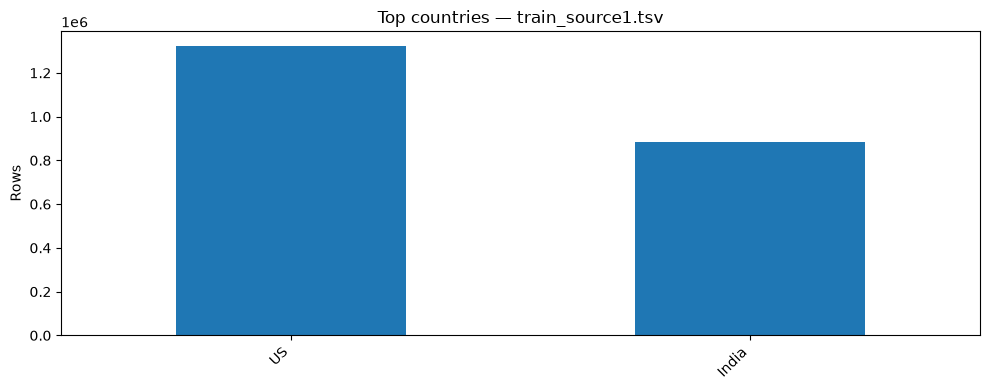


train_source2.tsv


,count
US,3016817
India,2017799


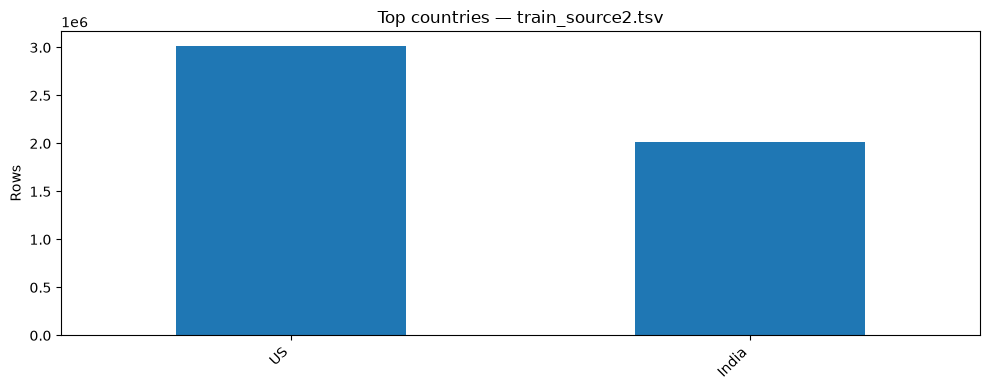


train_source3.tsv


,count
US,3170056
India,2115547


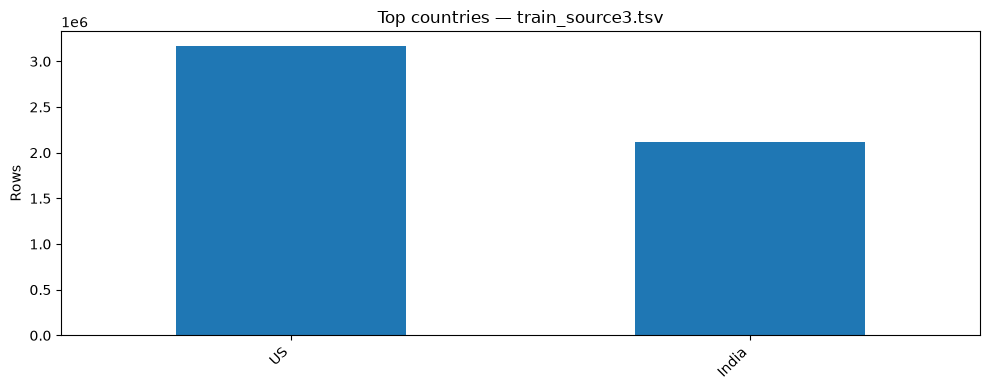

In [11]:
# =========================
# 5. Country distributions
# =========================

def country_counts(path, chunksize=CHUNK_SIZE):
    counter = Counter()

    for chunk in pd.read_csv(
        path,
        sep="\t",
        dtype=str,
        keep_default_na=False,
        usecols=["country"],
        chunksize=chunksize
    ):
        counter.update(chunk["country"].astype(str).str.strip())

    return pd.Series(dict(counter)).sort_values(ascending=False)

country_counts_by_source = {}

for filename in ["train_source1.tsv", "train_source2.tsv", "train_source3.tsv"]:
    counts = country_counts(DATA_DIR / filename)
    country_counts_by_source[filename] = counts

    print(f"\n{filename}")
    display(counts.head(20).to_frame("count"))

    counts.head(15).plot(kind="bar", figsize=(10, 4), title=f"Top countries — {filename}")
    plt.ylabel("Rows")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


# 6. Text EDA

Now inspect the raw business names and addresses.

We are looking for evidence of:
- punctuation variation
- capitalization variation
- abbreviations
- legal suffixes
- word-order changes
- transliteration
- missing address components
- numeric components
- very short / empty fields
- unusually long strings

This is exploratory only. We will use these observations later to design preprocessing and blocking.


In [13]:
# =========================
# 6A. Get a manageable random sample
# =========================

def sample_source(path, n=20_000, random_state=42):
    # Reservoir-like approach using pandas chunks.
    # Keeps memory bounded.
    samples = []
    seen = 0

    for chunk in pd.read_csv(
        path,
        sep="\t",
        dtype=str,
        keep_default_na=False,
        chunksize=CHUNK_SIZE
    ):
        take = min(len(chunk), max(1, int(n * len(chunk) / max(1, summaries[path.name]["rows"]))))
        samples.append(chunk.sample(n=min(take, len(chunk)), random_state=random_state))
        seen += len(chunk)

    sample = pd.concat(samples, ignore_index=True)

    if len(sample) > n:
        sample = sample.sample(n=n, random_state=random_state)

    return sample.reset_index(drop=True)

s1_sample = sample_source(DATA_DIR / "train_source1.tsv")
s2_sample = sample_source(DATA_DIR / "train_source2.tsv")
s3_sample = sample_source(DATA_DIR / "train_source3.tsv")

print("Samples:")
print("S1:", s1_sample.shape)
print("S2:", s2_sample.shape)
print("S3:", s3_sample.shape)


Samples:
S1: (19993, 4)
S2: (19987, 4)
S3: (19979, 4)


In [14]:
# =========================
# 6B. Missing / empty values in samples
# =========================

for name, df in [("S1", s1_sample), ("S2", s2_sample), ("S3", s3_sample)]:
    print(f"\n{name}")
    display(pd.DataFrame({
        "empty_count": (df[SOURCE_COLUMNS] == "").sum(),
        "empty_pct": ((df[SOURCE_COLUMNS] == "").mean() * 100).round(3),
    }))



S1


,empty_count,empty_pct
entity_id,0,0.0
business_name,0,0.0
business_address,0,0.0
country,0,0.0



S2


,empty_count,empty_pct
entity_id,0,0.000
business_name,0,0.000
business_address,693,3.467
country,0,0.000



S3


,empty_count,empty_pct
entity_id,0,0.000
business_name,0,0.000
business_address,631,3.158
country,0,0.000


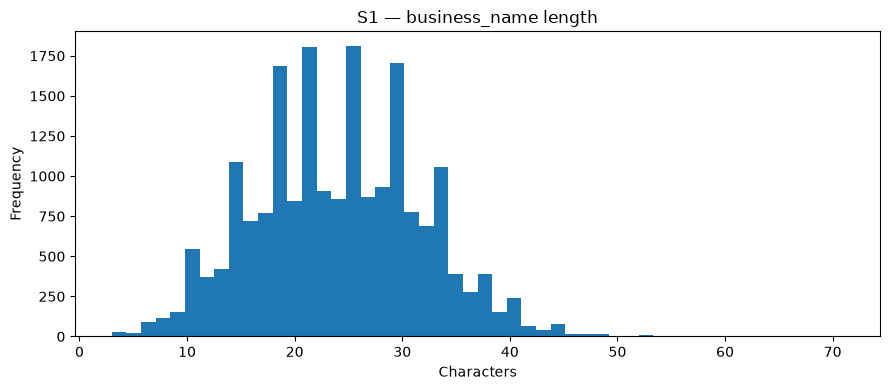

S1 business_name | mean = 24.07 | median = 24.0 | p95 = 37.0 | max = 71


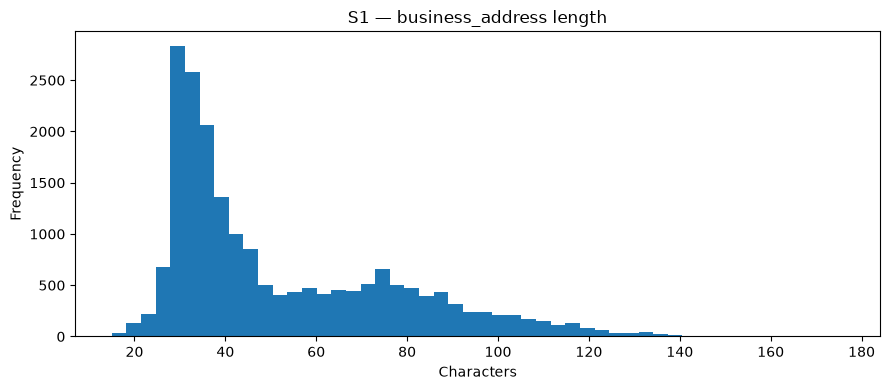

S1 business_address | mean = 52.25 | median = 41.0 | p95 = 103.4 | max = 176


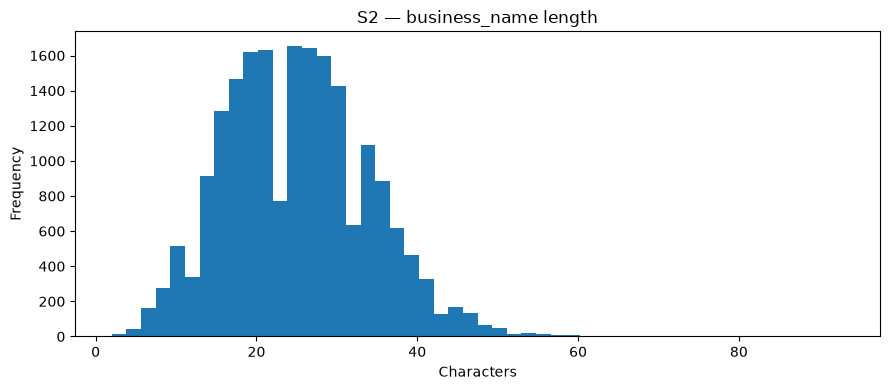

S2 business_name | mean = 25.04 | median = 25.0 | p95 = 40.0 | max = 93


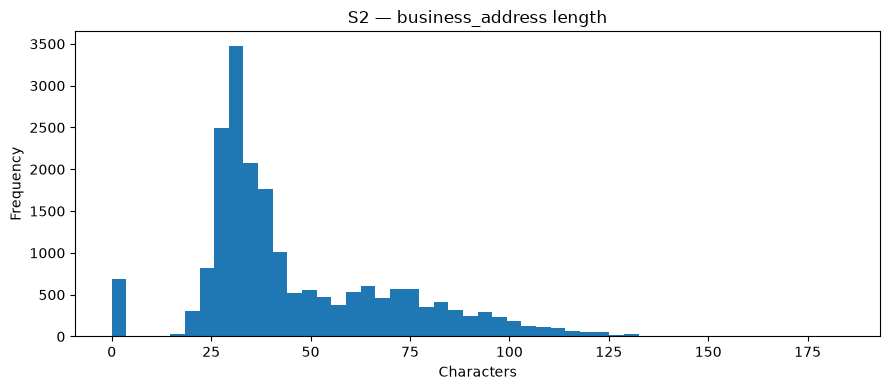

S2 business_address | mean = 46.2 | median = 37.0 | p95 = 96.0 | max = 184


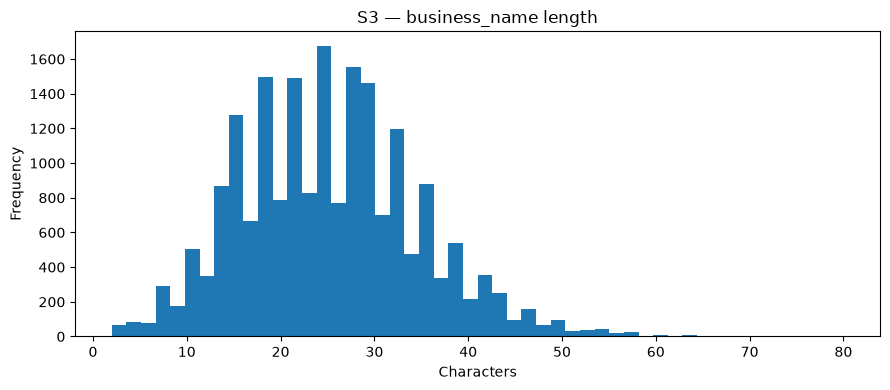

S3 business_name | mean = 25.23 | median = 25.0 | p95 = 42.0 | max = 80


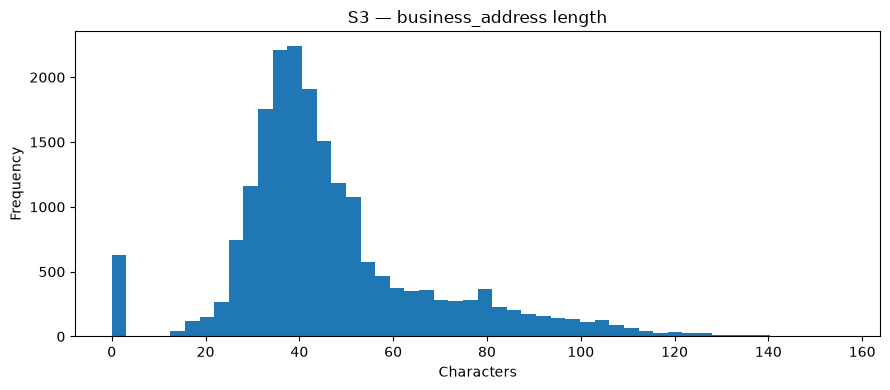

S3 business_address | mean = 46.6 | median = 41.0 | p95 = 91.0 | max = 156


In [15]:
# =========================
# 6C. Character-length distributions
# =========================

for name, df in [("S1", s1_sample), ("S2", s2_sample), ("S3", s3_sample)]:
    for col in ["business_name", "business_address"]:
        lengths = df[col].astype(str).str.len()

        plt.figure(figsize=(9, 4))
        plt.hist(lengths, bins=50)
        plt.title(f"{name} — {col} length")
        plt.xlabel("Characters")
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.show()

        print(
            name, col,
            "| mean =", round(lengths.mean(), 2),
            "| median =", lengths.median(),
            "| p95 =", round(lengths.quantile(.95), 2),
            "| max =", lengths.max()
        )


In [16]:
# =========================
# 6D. Inspect raw examples
# =========================

print("Random S1 examples:")
display(s1_sample[["entity_id", "business_name", "business_address", "country"]].sample(30, random_state=1))

print("\nRandom S2 examples:")
display(s2_sample[["entity_id", "business_name", "business_address", "country"]].sample(30, random_state=1))

print("\nRandom S3 examples:")
display(s3_sample[["entity_id", "business_name", "business_address", "country"]].sample(30, random_state=1))


Random S1 examples:


,entity_id,business_name,business_address,country
15941,S1-849202105,Moody Assets,"720 Cherry Lane, Arlington Heights, IL",US
6612,S1-804825374,Professional Telecom Advisors LLC,"Bastrop, TX, 1614 95",US
3283,S1-27032841,Sns Contractors Private Limited,"Rk Prasad Chawl No.3, Room No.6 Kaju, Kajuwadi...",India
13365,S1-71141297,Services Personal Solutions Corporation,"Sco-27, Cabin-1, Ii Floor, Jail Complex Sohna ...",India
10883,S1-278143749,Galaxy Solutions Private Limited,"A-1403, Supreme Willows Cst No- 403 To 406, 40...",India
4646,S1-423860957,Chandrendra Labs Private Limited,"C/O.- Bidhan Chandra Hati, Banamalipur P.O Kes...",India
4611,S1-757224349,Az Promotions Limited,"Fl-B-203, Shriram Pride, Sr No. 680/5A/1/13, P...",India
18929,S1-37163758,Complete Data Laboratories Inc,"3231 Gatewood Ford Road, Fentress County, TN",US
12131,S1-896680041,Daix LLC,"421 River Road, Orrington, ME",US
14160,S1-639432028,Zanet,"14 Curtis Road, Needham, MA",US



Random S2 examples:


,entity_id,business_name,business_address,country
9435,S2-632167445,Moore's Technologies [Inc],"13621. 155TH ST, GILBERT, AZ",US
1242,S2-700137534,"The Ridge Delta Wisekey, Corp","2211-C LAWRENCE RD, NULL, MANHATTAN, KS",US
14013,S2-925626074,गुरु ग्रेट लॉजिस्टिक्स प्रा. लि.,"MUMBAI, DOOR NO 4 VISHAL APARTMENTSL T ROAD BO...",India
14660,S2-805021885,Belda Private Limited Center,C/O SOMNATH GHOSH PLOT NO 1-376 & 391 J.L NO 3...,India
16242,S2-510412516,VASUDHA SEVA SMTTÍ,,India
13843,S2-872798425,"Merrill, Lydia Green Keycorp Inc","400 EMERY PARK RD, GOLDEN VALLEY, AZ",US
15887,S2-425378478,Prime Media Studios,"2084- RUSTIC TRAIL, MOGADORE, OH",US
11049,S2-632977252,Private Shyam Industries Limited,"ಕರ್ನಾಟಕ, BANGALORE NORTH, BANGALORE, NO B3/252...",India
4883,S2-744361149,Gori Law Chambers Clinic Holdings,"HN 55 8, HUMAYUN PALACE, NEAR NEW MARKET SHREE...",India
3501,S2-217759371,doo.com,"47D ROOSEVELT ST, NEW BEDFORD, MA",US



Random S3 examples:


,entity_id,business_name,business_address,country
6203,S3-862866127,supremeconstruction.com,"H.no 1/335, Ground Floor, Ganda Nala Punja Sha...",India
4209,S3-177601467,United League PLLC Council,"7410 Coldwater Road, Williamson County, Tennessee",US
13343,S3-33090572,EW Delta Repair Auto,"3305 Double Ealge Ln, Opelika, Alabama",US
12489,S3-242224640,Smk Realities Private Ltd,"21, Prestige Plaza 2, Opp Formica Ltd Akurdi, ...",India
13991,S3-461618896,Ravina Lifestyle Pamivaate Limited,"Door No 584 1-37, Chinthalapudi, AP",India
14299,S3-646697605,SQ Snow,"3285 Canyon Dr, # Unit 37, Billiings, Montana",US
13674,S3-25604283,Seven Investments Pvt Ltd,"04 Flat No.a-7, Aurangabad, MH",India
5036,S3-629714932,सूर्य बिजनेस,"222, Mumbai City, Bombay, MH",India
5264,S3-554644399,Ltd Hinton Colonial Salaan,"1606 Second Avenue, Des Moines, Iowa",US
1955,S3-115506167,Krishna Industries Private,"31/150/A, 31/150/B, Chanthappadi, Ponnani, Mal...",India


# 7. Token-level exploration

Before deciding how to normalize names, inspect common tokens.

This can reveal:
- company/legal suffixes
- common stopwords
- location words
- generic business terms
- source-specific patterns

We are **not removing these tokens yet**.


In [17]:
# =========================
# 7A. Common name tokens
# =========================

def tokenize_simple(text):
    return re.findall(r"\b\w+\b", str(text).lower())

def common_tokens(series, top_n=50):
    counter = Counter()

    for text in series.astype(str):
        counter.update(tokenize_simple(text))

    return pd.DataFrame(counter.most_common(top_n), columns=["token", "count"])

for name, df in [("S1", s1_sample), ("S2", s2_sample), ("S3", s3_sample)]:
    print(f"\n{name} common name tokens")
    display(common_tokens(df["business_name"], 50))



S1 common name tokens


,token,count
0,limited,4795
1,private,3969
2,llc,3092
3,inc,2156
4,ltd,1372
5,pvt,1117
6,india,544
7,care,533
8,and,494
9,c,490



S2 common name tokens


,token,count
0,llc,2203
1,ट,2143
2,private,2122
3,limited,2095
4,inc,1554
5,ltd,1552
6,र,1350
7,ल,1204
8,ड,1030
9,म,994



S3 common name tokens


,token,count
0,limited,2491
1,private,2426
2,llc,2198
3,ltd,1624
4,inc,1568
5,ट,1165
6,center,817
7,pvt,804
8,com,788
9,र,707


In [18]:
# =========================
# 7B. Common address tokens
# =========================

for name, df in [("S1", s1_sample), ("S2", s2_sample), ("S3", s3_sample)]:
    print(f"\n{name} common address tokens")
    display(common_tokens(df["business_address"], 50))



S1 common address tokens


,token,count
0,road,4286
1,no,4034
2,delhi,2961
3,street,2783
4,drive,1907
5,unit,1824
6,avenue,1735
7,maharashtra,1718
8,nagar,1521
9,floor,1478



S2 common address tokens


,token,count
0,no,4432
1,road,2616
2,delhi,1886
3,street,1332
4,st,1307
5,rd,1307
6,floor,1286
7,maharashtra,1243
8,1,1227
9,city,1212



S3 common address tokens


,token,count
0,no,4012
1,road,2214
2,new,1779
3,delhi,1571
4,city,1368
5,street,1361
6,1,1311
7,north,1294
8,st,1268
9,rd,1255


# 8. Ground-truth EDA

This is the most important EDA section.

For every S1 entity, `matched_entity_ids` contains zero, one, or multiple matching S2/S3 records.

We want to understand:
- how many S1 entities have no matches
- how many have one match
- how many have multiple matches
- distribution of match counts
- whether matches tend to come from S2, S3, or both


In [19]:
# =========================
# 8A. Load ground truth
# =========================

gt = pd.read_csv(
    DATA_DIR / "train_ground_truth.tsv",
    sep="\t",
    dtype=str,
    keep_default_na=False
)

print("Shape:", gt.shape)
print("Columns:", gt.columns.tolist())
display(gt.head(10))


Shape: (2206821, 2)
Columns: ['source1_entity_id', 'matched_entity_ids']


,source1_entity_id,matched_entity_ids
0,S1-965667,"S2-681193310,S2-743505751,S3-775321672,S3-1129..."
1,S1-55344266,"S2-249013014,S2-197070651,S3-478195123,S3-3843..."
2,S1-343815751,"S2-790675320,S2-479876582,S3-878454467"
3,S1-656753428,"S2-153058913,S2-24659151,S3-679606215"
4,S1-102811957,"S2-478959098,S2-553508714,S2-625774905,S3-7280..."
5,S1-18727616,"S2-755677256,S3-187831601,S3-641489370,S3-4762..."
6,S1-318373630,"S2-660036492,S3-804600254"
7,S1-86989137,"S3-274817120,S3-312496301"
8,S1-29845983,"S2-648035184,S3-588502663"
9,S1-789009573,"S2-383871912,S3-74481402,S3-576451439"


In [20]:
# =========================
# 8B. Parse matched IDs
# =========================

def split_matches(x):
    x = str(x).strip()
    if not x:
        return []
    return [v.strip() for v in x.split(",") if v.strip()]

gt["matched_list"] = gt["matched_entity_ids"].apply(split_matches)
gt["match_count"] = gt["matched_list"].str.len()

print("Match-count distribution:")
display(
    gt["match_count"]
      .value_counts()
      .sort_index()
      .rename_axis("number_of_matches")
      .to_frame("S1_entities")
)

print("\nPercentages:")
display(
    (gt["match_count"].value_counts(normalize=True).sort_index() * 100)
    .round(3)
    .rename_axis("number_of_matches")
    .to_frame("percentage")
)


Match-count distribution:


,S1_entities
number_of_matches,
0,123247
1,119157
2,375212
3,530841
4,484115
5,321957
6,164868
7,63968
8,18680



Percentages:


,percentage
number_of_matches,
0,5.585
1,5.399
2,17.002
3,24.055
4,21.937
5,14.589
6,7.471
7,2.899
8,0.846


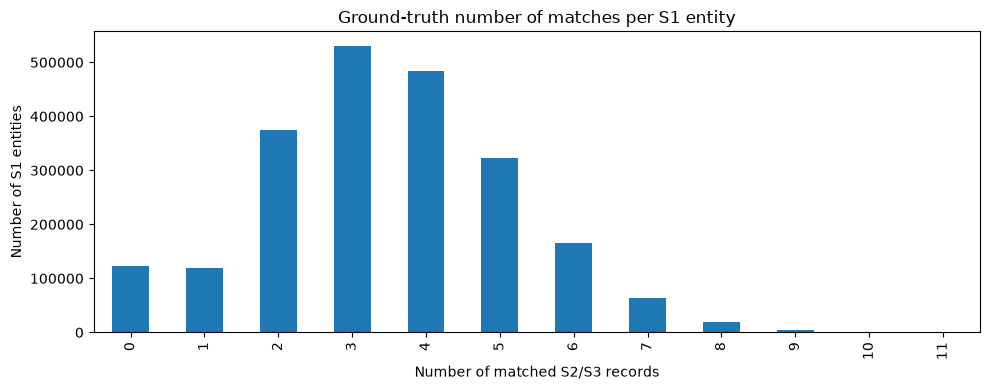

In [21]:
# =========================
# 8C. Match-count plot
# =========================

plt.figure(figsize=(10, 4))
gt["match_count"].value_counts().sort_index().plot(kind="bar")
plt.title("Ground-truth number of matches per S1 entity")
plt.xlabel("Number of matched S2/S3 records")
plt.ylabel("Number of S1 entities")
plt.tight_layout()
plt.show()


In [22]:
# =========================
# 8D. S2 vs S3 vs both
# =========================

def source_of_id(entity_id):
    if entity_id.startswith("S2-"):
        return "S2"
    if entity_id.startswith("S3-"):
        return "S3"
    return "OTHER"

def match_source_pattern(matches):
    sources = {source_of_id(x) for x in matches}
    if not sources:
        return "NONE"
    if sources == {"S2"}:
        return "S2 only"
    if sources == {"S3"}:
        return "S3 only"
    if sources == {"S2", "S3"}:
        return "Both S2 + S3"
    return "OTHER"

gt["match_source_pattern"] = gt["matched_list"].apply(match_source_pattern)

display(
    gt["match_source_pattern"]
    .value_counts()
    .rename_axis("pattern")
    .to_frame("S1_entities")
)


,S1_entities
pattern,
Both S2 + S3,1776047
S3 only,164498
S2 only,143029
NONE,123247


# 9. Ground-truth examples

Look at real positive examples before designing similarity features.

This is where we want to see the actual noise described in the challenge:
- abbreviations
- legal suffixes
- punctuation
- typos
- word-order changes
- DBA/trade names
- address abbreviations
- transliteration
- missing address components


In [23]:
# =========================
# 9. Show matched examples
# =========================

# Load small lookup samples from each source.
# For a first pass, load only rows whose IDs occur in a random GT sample.

example_gt = gt.sample(min(30, len(gt)), random_state=42).explode("matched_list")
example_gt = example_gt[example_gt["matched_list"].notna()].copy()

s1_ids = set(example_gt["source1_entity_id"])
matched_ids = set(example_gt["matched_list"])

def load_rows_by_ids(path, wanted_ids, chunksize=CHUNK_SIZE):
    pieces = []

    for chunk in pd.read_csv(
        path,
        sep="\t",
        dtype=str,
        keep_default_na=False,
        chunksize=chunksize
    ):
        hit = chunk[chunk["entity_id"].isin(wanted_ids)]
        if not hit.empty:
            pieces.append(hit)

    if pieces:
        return pd.concat(pieces, ignore_index=True)
    return pd.DataFrame(columns=SOURCE_COLUMNS)

example_s1 = load_rows_by_ids(DATA_DIR / "train_source1.tsv", s1_ids)
example_s2 = load_rows_by_ids(DATA_DIR / "train_source2.tsv", {x for x in matched_ids if x.startswith("S2-")})
example_s3 = load_rows_by_ids(DATA_DIR / "train_source3.tsv", {x for x in matched_ids if x.startswith("S3-")})

print("S1 examples:", example_s1.shape)
print("S2 matched examples:", example_s2.shape)
print("S3 matched examples:", example_s3.shape)

display(example_gt[["source1_entity_id", "matched_list"]].head(30))


S1 examples: (29, 4)
S2 matched examples: (56, 4)
S3 matched examples: (52, 4)


,source1_entity_id,matched_list
2195840,S1-384734976,S2-685146894
2195840,S1-384734976,S2-908470079
2195840,S1-384734976,S3-109845102
2195840,S1-384734976,S3-176459320
1487051,S1-574038342,S2-133116927
1487051,S1-574038342,S2-180265553
1487051,S1-574038342,S2-201976425
993966,S1-797774718,S2-151469064
993966,S1-797774718,S3-994706509
565428,S1-729164458,S2-619382517


In [24]:
# =========================
# 9B. Human-readable matched pairs
# =========================

s1_lookup = example_s1.set_index("entity_id").to_dict("index")
s2_lookup = example_s2.set_index("entity_id").to_dict("index")
s3_lookup = example_s3.set_index("entity_id").to_dict("index")

rows = []

for _, r in example_gt.iterrows():
    s1_id = r["source1_entity_id"]
    target = r["matched_list"]

    if s1_id not in s1_lookup:
        continue

    s1row = s1_lookup[s1_id]

    for mid in [target]:
        lookup = s2_lookup if mid.startswith("S2-") else s3_lookup
        if mid not in lookup:
            continue

        mrow = lookup[mid]

        rows.append({
            "S1_ID": s1_id,
            "S1_name": s1row["business_name"],
            "S1_address": s1row["business_address"],
            "S1_country": s1row["country"],
            "match_ID": mid,
            "match_name": mrow["business_name"],
            "match_address": mrow["business_address"],
            "match_country": mrow["country"],
        })

matched_examples_df = pd.DataFrame(rows)
display(matched_examples_df)


,S1_ID,S1_name,S1_address,S1_country,match_ID,match_name,match_address,match_country
0,S1-384734976,"FQ Social, Inc","1212 Old Rte 34, Sandwich, IL",US,S2-685146894,"FQ Social, Inc.","1212 OLD RTE 34, SANDWICH, IL",US
1,S1-384734976,"FQ Social, Inc","1212 Old Rte 34, Sandwich, IL",US,S2-908470079,"FQ Social, #42836","1212 OLD RTE 34, SANDWICH, IL",US
2,S1-384734976,"FQ Social, Inc","1212 Old Rte 34, Sandwich, IL",US,S3-109845102,"FQ Social, Ínc","1212 Old Rte 34, Sandwich, Illinois",US
3,S1-384734976,"FQ Social, Inc","1212 Old Rte 34, Sandwich, IL",US,S3-176459320,"Arcxylo DBA FQ Social, Inc","1212 Old Rte 34, Sandwich, IL",US
4,S1-574038342,Innovative Consultants,"15 16 Indrapuri Madhubancolony Karvenagar, Pun...",India,S2-133116927,इनोवेटिव कंसल्टेंट्स,H.NO B3/15 16 INDRAPURI MADHUBANCOLONY KARVENA...,India
...,...,...,...,...,...,...,...,...
103,S1-975567345,Ruby Auto Pvt Ltd,"Flat No.310, 25-16-144/D, Latha Homes, Chuttug...",India,S3-734455243,Ruby Pvt Ltd Partners,"Flat No.31, 25-16-144/D, Latha Homes, Chuttugu...",India
104,S1-975567345,Ruby Auto Pvt Ltd,"Flat No.310, 25-16-144/D, Latha Homes, Chuttug...",India,S3-986861690,M/s Ruby Aruo Pvt Ltd,"No 31, 25-16-144/D, Latha Homes, Chuttugunta M...",India
105,S1-975567345,Ruby Auto Pvt Ltd,"Flat No.310, 25-16-144/D, Latha Homes, Chuttug...",India,S3-360593542,Ruby Pvt-Ltd Center,"Guntur, Flat No.31, 25-16-144/D, Latha Homes, ...",India
106,S1-975567345,Ruby Auto Pvt Ltd,"Flat No.310, 25-16-144/D, Latha Homes, Chuttug...",India,S3-281256504,Ruby Auto Pvt Limited,"31, Guntur, AP",India


# 10. Duplicate / near-duplicate exploration

Exact duplicate names are useful to know because they can make naive name matching ambiguous.

We inspect:
- exact duplicate normalized-looking names (without actually creating the production normalizer)
- repeated raw business names
- repeated addresses

This helps us understand whether **name alone** can identify an entity.


In [25]:
# =========================
# 10A. Repeated raw names in samples
# =========================

for name, df in [("S1", s1_sample), ("S2", s2_sample), ("S3", s3_sample)]:
    vc = df["business_name"].astype(str).str.strip().value_counts()
    print(f"\n{name}: repeated raw business names")
    display(vc[vc > 1].head(30).to_frame("count"))



S1: repeated raw business names


,count
business_name,
Eye Group,5
Meridian,5
Big Logistics Private Limited,4
Urology Group,4
Bastion LLC,4
Ear Nose & Throat Group,4
Twisted Book Store,4
Anchor LLC,4
Urgent Care Physicians Inc,4



S2: repeated raw business names


,count
business_name,
Womens Health,4
Family Associates,3
Red Pizza,2
Dermatology-Medicine,2
Primary Care,2
Behavioral Health Gróup,2
Cypress LLC,2
వైట్ ఇన్ఫోటెక్ ప్రైవేట్ లిమిటెడ్,2
एसएस कंसल्टेंट्स प्राइवेट लिमिटेड,2



S3: repeated raw business names


,count
business_name,
Pediatric Dental,6
Womens Health,4
Internal Medicine,3
Physical Therapy,3
New Delhi,3
The Dent,3
DI,3
Services,3
Literacy Center,2


In [26]:
# =========================
# 10B. Repeated raw addresses in samples
# =========================

for name, df in [("S1", s1_sample), ("S2", s2_sample), ("S3", s3_sample)]:
    vc = df["business_address"].astype(str).str.strip().value_counts()
    print(f"\n{name}: repeated raw addresses")
    display(vc[vc > 1].head(30).to_frame("count"))



S1: repeated raw addresses


,count
business_address,
"Pl No 33 Ashirwad Taraju Co-Op Housing Society Mahavir Nagar, Kolhapur, Maharashtra",2
"1225 Medlock Drive, Unit 202, Phoenix, AZ",2
"13261 Aleppo Drive, Sun City West, AZ",2
"5767 Arnold Road, Rice Lake, MN",2
"1410 Main Boulevard, Brownwood, TX",2
"16230 Crossing Circle, Lindale, TX",2
"49424 Co Hwy 14, New York Mills, MN",2
"1501 108th Street, Cleveland, OH",2
"615 Quince Avenue, Upland, CA",2



S2: repeated raw addresses


,count
business_address,
,693
"030 RAMPASTURE RD, SOUTHAMPTON, NY",2
"H-11 SECTOR-11, NOIDA, NULL, Uttar Pradesh",2
"364 CALLIS FIELD LN, NULL, MATHEWWS, VA",2
"231 INDIAN PARK DR, MURFREESBORO, TN",2
"154 DOG PATCH LANE, SAR, NC",2
"56 1/2 CRAIGHEAD 518 ROAD, NULL, MONETTE, AR",2
"CHOWDHURYBHAWAN, SOUTHDESHBANDHUPARAP.O.-SILIGURITOWN, West Bengal",2
"849 1/2 SABINE AVE, PORT ARTHUR, TX",2



S3: repeated raw addresses


,count
business_address,
,631
"Plot 254 C/o Paran Halder, Bagda, Naldugari, WB",2
"19, Mumbai, MH",2
"3468 109, Lexington, North Carolina",2
"1A-317, Avas Vikas, Baraut, Bagpat, UP",2
"29Quay Street Dharukhana, Mumbai, MH",2


# 11. Preliminary EDA conclusions

Do **not** fill this section automatically.

After running the notebook, record observations such as:

### Data quality
- Are names frequently missing?
- Are addresses frequently missing?
- Are there unexpected countries?
- Are IDs unique?

### Name noise
- Which abbreviations occur?
- Which legal suffixes occur?
- How often are names reordered?
- Are there transliterated names?

### Address noise
- Are postal codes present?
- Are city/locality names common?
- Are address numbers preserved?
- Which abbreviations are common?

### Ground truth
- What percentage of S1 entities have zero matches?
- What percentage have multiple matches?
- How often do entities match both S2 and S3?

### Implications for the next phase
Write concrete consequences for:
- normalization
- blocking
- candidate recall
- pair features
- handling no-match entities

The next notebook phase should start only after these observations are documented.


In [28]:
# =========================
# 12. Save compact EDA artifacts
# =========================

OUTPUT_DIR = Path("./eda_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Save ground-truth match distribution.
gt["match_count"].value_counts().sort_index().rename("S1_entities").to_csv(
    OUTPUT_DIR / "ground_truth_match_count_distribution.csv"
)

# Save source summaries.
pd.DataFrame(rows if False else [
    {
        "file": filename,
        "rows": info["rows"],
        "empty_name": info["empty_business_name"],
        "empty_address": info["empty_business_address"],
        "empty_country": info["empty_country"],
        "mean_name_len": info["name_len_mean"],
        "median_name_len": info["name_len_median"],
        "p95_name_len": info["name_len_p95"],
        "mean_address_len": info["address_len_mean"],
        "median_address_len": info["address_len_median"],
        "p95_address_len": info["address_len_p95"],
    }
    for filename, info in summaries.items()
]).to_csv(OUTPUT_DIR / "source_summary.csv", index=False)

print("Saved EDA summaries to:", OUTPUT_DIR.resolve())


Saved EDA summaries to: /Users/lakshmikotaru/amazon_ml_entity_resolution/code/business_entity_resolution/src/eda_outputs
